# 1. Importation de packages

In [50]:
import os
import pandas as pd
import numpy as np
import s3fs
from utils import charger_donnees_api, imputer_na_par_valeur, tracer_series_temporelles, sauvegarder_donnees_clean, classifier_risque, predire_risque

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

import joblib

from xgboost import XGBClassifier


# 2. Importation des données

On définit le dossier de données qui n'est créé que s'il n'existe pas encore dans le repertoire de travail.

In [51]:
DOSSIER_DONNEES = "data/raw"
os.makedirs(DOSSIER_DONNEES, exist_ok=True)

Nous importons ici les données sur les pollens via  l'api open-meteo (**air-quality** pour les données sur les pollens et **archives** pour les données météo); nous avons considéré les données sur un an du 1er janvier 2023 au 01 janvier 2024 pour Rennes.

Données Pollen

In [52]:
url_pollen = "https://air-quality-api.open-meteo.com/v1/air-quality"

params_pollen = {
    "latitude": 48.11,
    "longitude": -1.67,
    "hourly": ["birch_pollen", "grass_pollen"],
    "start_date": "2021-01-01",
    "end_date": "2026-04-19"
}

fichier_pollen = os.path.join(DOSSIER_DONNEES, "pollen.csv")


df_pol = charger_donnees_api(
    url=url_pollen,
    params=params_pollen,
    fichier_cache=fichier_pollen,
    force_reload= False
)


Données météo

In [53]:
url_meteo = "https://archive-api.open-meteo.com/v1/archive"

params_meteo = {
    "latitude": 48.11,
    "longitude": -1.67,
    "hourly": ["temperature_2m", "precipitation", "wind_speed_10m"],
    "start_date": "2021-01-01",
    "end_date": "2026-04-19",
    "timezone": "Europe/Paris"
}

fichier_meteo = os.path.join(DOSSIER_DONNEES, "meteo.csv")


df_met = charger_donnees_api(
    url=url_meteo,
    params=params_meteo,
    fichier_cache=fichier_meteo,
    force_reload= False
)

# 3.Fusion et analyse exploratoire

Pour éviter de travailler sur les bases originales, on va travailler sur les copies de ces bases.

In [54]:
df_meteo = df_met.copy()
df_pollen = df_pol.copy()

## 3.1. Fusion des bases
Pour répondre à la thématique, nous devons fusionner les deux bases; Mais avant  toute fusion, il faut vérifier la structure des deux bases et surtout explorer la clé de fusion qui ici est la date.
Ci-dessous, un aperçu des deux bases:

In [55]:
pd.concat(
    [df_pollen.head(), df_meteo.head()],
    axis=1,
    keys=["Pollen", "Meteo"]
)

Pollen                                         Meteo  \
                 date birch_pollen grass_pollen                date   
0 2021-01-01 00:00:00          0.0          0.0 2021-01-01 00:00:00   
1 2021-01-01 01:00:00          0.0          0.0 2021-01-01 01:00:00   
2 2021-01-01 02:00:00          0.0          0.0 2021-01-01 02:00:00   
3 2021-01-01 03:00:00          0.0          0.0 2021-01-01 03:00:00   
4 2021-01-01 04:00:00          0.0          0.0 2021-01-01 04:00:00   

                                               
  temperature_2m precipitation wind_speed_10m  
0           -0.4           0.0            2.9  
1           -1.4           0.0            2.1  
2           -1.9           0.0            3.6  
3           -2.5           0.0            2.3  
4           -2.5           0.0            4.3

Pour faciliter la lisibilité et la manipulation des variables, il est nécessaire de les renommer.

In [56]:
df_pollen = df_pollen.rename(columns={
    "birch_pollen": "pollen_bouleau",
    "grass_pollen": "pollen_graminees"
})

df_meteo = df_meteo.rename(columns={
    "temperature_2m": "temperature",
    "precipitation": "precipitations",
    "wind_speed_10m": "vitesse_vent"
})

pd.concat(
    [df_pollen.head(), df_meteo.head()],
    axis=1,
    keys=["Pollen", "Meteo"]
)

Pollen                                               Meteo  \
                 date pollen_bouleau pollen_graminees                date   
0 2021-01-01 00:00:00            0.0              0.0 2021-01-01 00:00:00   
1 2021-01-01 01:00:00            0.0              0.0 2021-01-01 01:00:00   
2 2021-01-01 02:00:00            0.0              0.0 2021-01-01 02:00:00   
3 2021-01-01 03:00:00            0.0              0.0 2021-01-01 03:00:00   
4 2021-01-01 04:00:00            0.0              0.0 2021-01-01 04:00:00   

                                           
  temperature precipitations vitesse_vent  
0        -0.4            0.0          2.9  
1        -1.4            0.0          2.1  
2        -1.9            0.0          3.6  
3        -2.5            0.0          2.3  
4        -2.5            0.0          4.3

Afin de garantir l'intégrité de nos deux bases qui sont temporelles, nous vérifions la régularité du pas de temps via le calcul des différences successives (.diff()). Cette étape confirme la continuité des observations horaires et l'absence de dates manquantes.

In [57]:
pd.concat(
    [df_pollen["date"].diff().value_counts().head(), df_meteo["date"].diff().value_counts().head()],
    axis=1,
    keys=["Pollen", "Meteo"]
)

,Pollen,Meteo
date,,
0 days 01:00:00,46439,46439


Vérifions que les périodes se chevauchent pour les deux bases. ça devrait être le cas au regard des paramètres d'importation mais la vérification en vaut la peine.

In [58]:
pd.DataFrame({
    "Pollen": [df_pollen["date"].min(), df_pollen["date"].max()],
    "Meteo": [df_meteo["date"].min(), df_meteo["date"].max()]
}, index=["Min date", "Max date"])

,Pollen,Meteo
Min date,2021-01-01 00:00:00,2021-01-01 00:00:00
Max date,2026-04-19 23:00:00,2026-04-19 23:00:00


On remarque que les données des deux bases sont sans fuseau attachés, ce qui facilite la fusion locale en prenant la date comme clé de fusion.

In [59]:
print(df_meteo["date"].dt.tz)
print(df_pollen["date"].dt.tz)

None
None


On se rend également compte qu'avant la fusion, il n y a pas de valeur manquante dans la base météo.

In [60]:
pd.concat(
    [df_pollen.isnull().sum(), df_meteo.isnull().sum()],
    axis=1,
    keys=["Pollen", "Meteo"]
)

,Pollen,Meteo
date,0.0,0.0
pollen_bouleau,12791.0,NaN
pollen_graminees,10559.0,NaN
temperature,NaN,0.0
precipitations,NaN,0.0
vitesse_vent,NaN,0.0


**Fusion des deux bases**
Fusion des deux bases: avec toutes les vérifications qui viennent d'être faites sur la variable date qui est la clé primaire ici, on  peut fusionner simplement avec un inner_join (correspondances exactes)

In [61]:
df_pollen_meteo = pd.merge(df_pollen, df_meteo, on="date", how="inner")

df_pollen_meteo.to_csv("data/raw/df_pollen_meteo_merge.csv")

print(df_pollen_meteo.shape)
df_pollen_meteo.head()

(46440, 6)


,date,pollen_bouleau,pollen_graminees,temperature,precipitations,vitesse_vent
0,2021-01-01 00:00:00,0.0,0.0,-0.4,0.0,2.9
1,2021-01-01 01:00:00,0.0,0.0,-1.4,0.0,2.1
2,2021-01-01 02:00:00,0.0,0.0,-1.9,0.0,3.6
3,2021-01-01 03:00:00,0.0,0.0,-2.5,0.0,2.3
4,2021-01-01 04:00:00,0.0,0.0,-2.5,0.0,4.3


## 3.2. Exploration et traitement de la base d'étude

In [62]:
print("\n--- Informations détaillées (Check-up complet) ---")
df_pollen_meteo.info()


--- Informations détaillées (Check-up complet) ---
<class 'pandas.DataFrame'>
RangeIndex: 46440 entries, 0 to 46439
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              46440 non-null  datetime64[us]
 1   pollen_bouleau    33649 non-null  float64       
 2   pollen_graminees  35881 non-null  float64       
 3   temperature       46440 non-null  float64       
 4   precipitations    46440 non-null  float64       
 5   vitesse_vent      46440 non-null  float64       
dtypes: datetime64[us](1), float64(5)
memory usage: 2.1 MB


In [63]:
df_pollen_meteo.isnull().sum()

date                    0
pollen_bouleau      12791
pollen_graminees    10559
temperature             0
precipitations          0
vitesse_vent            0
dtype: int64


**Interprétation des valeurs manquantes**

L’analyse des périodes manquantes montre qu’elles correspondent en réalité à des **phases biologiques naturelles** et non à des erreurs de collecte de données.

Pour le pollen de bouleau, les données sont absentes de janvier à fin février, ce qui correspond à une période de dormance. Elles sont présentes de mars à début août, période de pollinisation, puis redeviennent absentes à partir d’août jusqu'au 20 novembre, marquant la fin de la saison.

Pour les graminées, les données sont également absentes en hiver (janvier-février), présentes de mars à début septembre, ce qui reflète une saison de pollinisation plus longue, puis absentes à nouveau à partir de septembre jusqu'au 20 novembre.

Ces résultats sont cohérents avec les connaissances biologiques et confirment que les valeurs manquantes ne sont pas problématiques, mais traduisent simplement l’absence de pollen hors saison. Cela nous emmene donc à imputer ces valeurs manquantes par des 0.

In [64]:
from IPython.display import display, HTML
from utils import identifier_plages_manquantes

# Bouleau
display(HTML("<b>Périodes manquantes pour le Pollen de bouleau</b>"))
plages_bouleau = identifier_plages_manquantes(df_pollen_meteo, 'pollen_bouleau')
display(plages_bouleau)

# Graminées
display(HTML("<b>Périodes manquantes pour les graminées</b>"))
plages_graminees = identifier_plages_manquantes(df_pollen_meteo, 'pollen_graminees')
display(plages_graminees)

--- Analyse : pollen_bouleau ---
Total NaN dans la colonne : 12791
Total identifié par blocs : 12791
Vérification : OK (Tous les NaN sont comptabilisés).


,date_debut,date_fin,heures_manquantes,total_cumule_manquant
0,2021-08-01 00:00:00,2022-02-28 23:00:00,5088,5088
1,2022-08-01 00:00:00,2023-02-28 23:00:00,5088,10176
2,2023-08-04 01:00:00,2023-11-20 23:00:00,2615,12791


--- Analyse : pollen_graminees ---
Total NaN dans la colonne : 10559
Total identifié par blocs : 10559
Vérification : OK (Tous les NaN sont comptabilisés).


,date_debut,date_fin,heures_manquantes,total_cumule_manquant
0,2021-09-01 00:00:00,2022-02-28 23:00:00,4344,4344
1,2022-09-01 00:00:00,2023-02-28 23:00:00,4344,8688
2,2023-09-04 01:00:00,2023-11-20 23:00:00,1871,10559


Bien qu'après le 20 novembre 2023, les données ne soient pas manquantes pour ces deux variables de pollen, les valeurs qu'elles prennent sont nulles comme on peut le voir sur les graphiques plus bas;
Ce même comportement est observé pour les mêmes périodes des années 2024 et 2025;  ce qui est normal vu que la période novembre-decembre n'est pas leur saison. 

In [65]:
# Définition de la borne temporelle (juste après le dernier NaN)
date_reprise = "2023-11-20 23:00:00"

# Création du sous-ensemble de données pour la fin d'année
df_fin_annee = df_pollen_meteo[df_pollen_meteo['date'] > date_reprise].copy()

# Calcul des statistiques pour se rassurer
stats_fin_annee = df_fin_annee[['pollen_bouleau', 'pollen_graminees']].agg(['max', 'min','mean', 'sum', 'count'])

print(f"--- Analyse de la période : du {df_fin_annee['date'].min()} au {df_fin_annee['date'].max()} ---")
print(f"Nombre total d'heures analysées : {len(df_fin_annee)}")
print("\nStatistiques des pollens sur cette période :")
display(stats_fin_annee)

--- Analyse de la période : du 2023-11-21 00:00:00 au 2026-04-19 23:00:00 ---
Nombre total d'heures analysées : 21144

Statistiques des pollens sur cette période :


,pollen_bouleau,pollen_graminees
max,344.90000,136.500000
min,0.00000,0.000000
mean,2.40472,4.525435
sum,50845.40000,95685.800000
count,21144.00000,21144.000000


**Imputation des valeurs manquantes par 0**

In [66]:
colonnes_pollen = ['pollen_bouleau', 'pollen_graminees']

df_pollen_meteo_clean = imputer_na_par_valeur(df_pollen_meteo, colonnes_pollen)


# 3. Vérification finale
print("Nombre de valeurs manquantes après imputation :")
print(df_pollen_meteo_clean[colonnes_pollen].isna().sum())

Nombre de valeurs manquantes après imputation :
pollen_bouleau      0
pollen_graminees    0
dtype: int64


In [67]:
sauvegarder_donnees_clean(
    df=df_pollen_meteo_clean,
    nom_fichier="df_pollen_meteo_clean.csv",
    dossier="data/clean"
)

Données sauvegardées dans : data/clean/df_pollen_meteo_clean.csv


#### Variables polliniques — Bouleau & Graminées

**Saisonnalité stricte et récurrente**  
Les deux espèces présentent une phénologie (cycles de vie selon le climat et la saison) remarquablement stable : le pic de bouleau se produit chaque année en mars–avril, immédiatement suivi du pic de graminées en mai–juillet. Cette régularité calendaire constitue un signal prédictif fort — la
variable `jour_de_l_année` (avec un  encodage sinusoïdal) sera vraisemblablement un prédicteur
très discriminant du modèle.

**Variabilité inter-annuelle marquée**  
L'intensité des pics fluctue fortement d'une année à l'autre, indépendamment de leur
date d'occurrence. Le pic de bouleau de 2021 dépasse 500 grains/m³, tandis que celui
de 2024 plafonne à ~150 grains/m³ — soit un facteur ×3. Cette variance inter-annuelle
suggère que des conditions météorologiques spécifiques à chaque saison (températures
hivernales, gel tardif, pluviométrie printanière) modulerait  l'intensité de
la saison pollinique. Le modèle devra capturer ces interactions.

**Distribution fortement asymétrique ("zero-inflated")**  
Les concentrations sont nulles ou quasi-nulles sur environ 75–80 % de l'année. La
cible est donc déséquilibrée par construction : les pics sont rares, brefs et intenses.
En classification, on devra éventuellement faire un rééquilibrage de classes
(SMOTE ou `class_weight='balanced'`) ; 



#### Variables météorologiques

**Température** *(signal principal)*  
La courbe sinusoïdale annuelle coïncide visuellement avec
les fenêtres d'émission pollinique : les pics ne semblent se déclencher qu'au-dessus d'un
seuil de douceur printanière. 

**Précipitations** *(effet "lavage atmosphérique")*  
Les précipitations sont très sporadiques (distribution Poisson-like, avec
des pics à 12–14 mm). Leur effet principal attendu est un lessivage rapide des
particules en suspension : une pluie significative fait chuter par hypothèse les concentrations dans
les 24–48 h. Ce mécanisme justifierait l'inclusion d'un **lag de 1–2 jours** sur les
précipitations, en plus de la valeur courante.

**Vitesse du vent** *(disperseur ambivalent)*  
Le signal est bruité et haute-fréquence (variabilité journalière importante à Rennes,
site côtier). L'effet sur le pollen est non-linéaire : un vent modéré favoriserait la
dispersion et augmente les concentrations locales, tandis qu'un vent fort tend à
diluer et à déplacer les masses d'air. Une transformation (ex. `log(vent + 1)`) ou
une discrétisation en classes (calme / modéré / fort) pourra être évaluée lors du feature
engineering.



#### Synthèse — implications pour la modélisation
Les  données seront agrégées pour avoir des données journalières afin garantir un minimum de stabilité.

| Observation | Action technique |
|---|---|
| Saisonnalité forte | Inclure`jour_de_lannee` comme features |
| Variabilité inter-annuelle | Ajouter lags météo (J-7, J-14) et rolling means |
| Distribution zero-inflated | Rééquilibrage + métrique adaptée (F1-macro, MAE) |
| Effet retardé pluie/vent | Features laggées à J-1 et J-2 |
| Non-linéarité vent | Transformation log ou discrétisation |

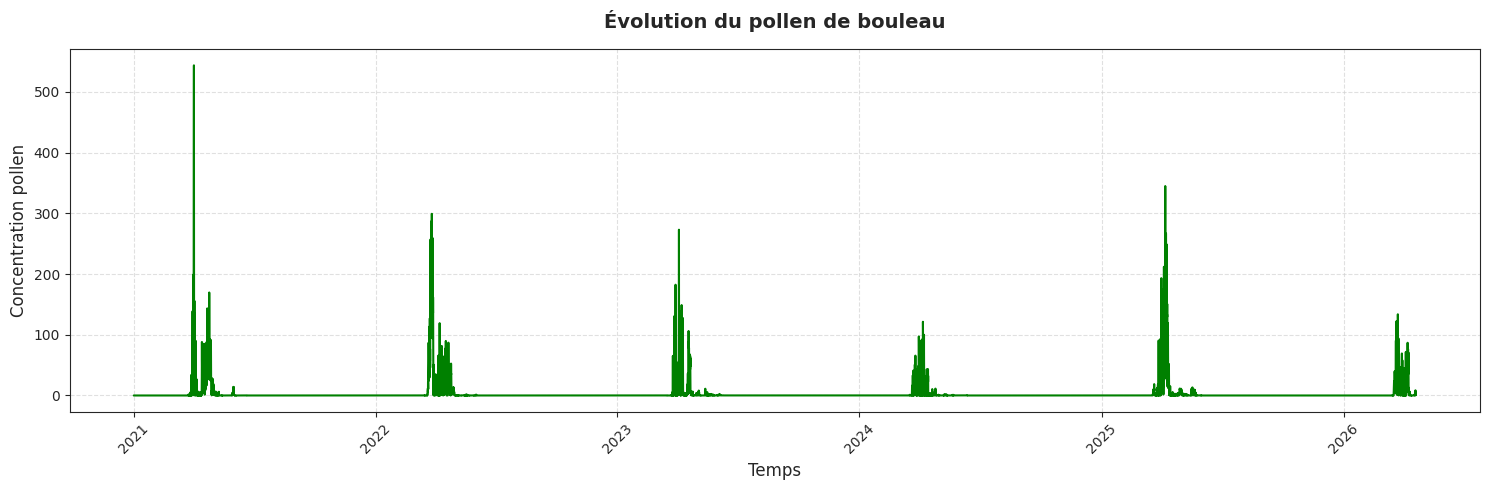

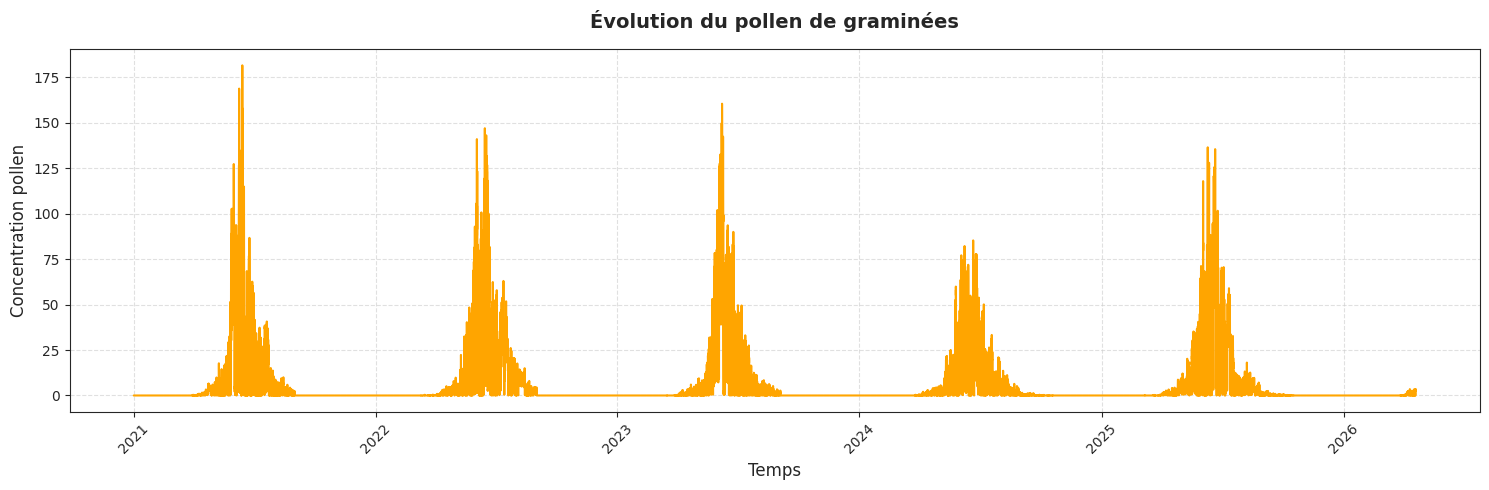

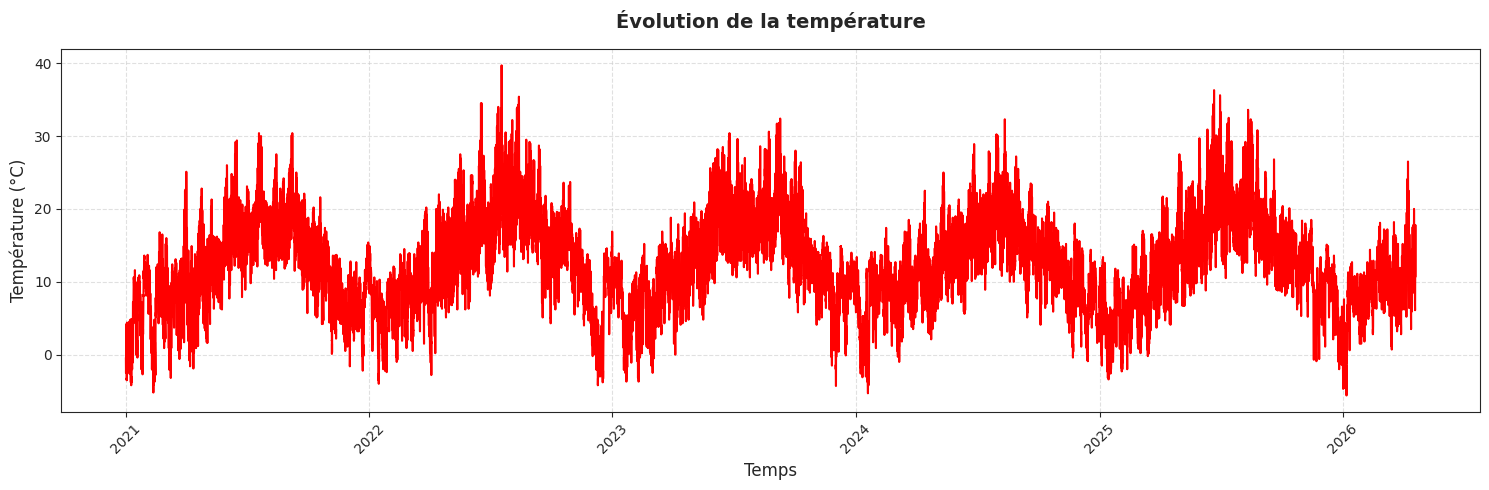

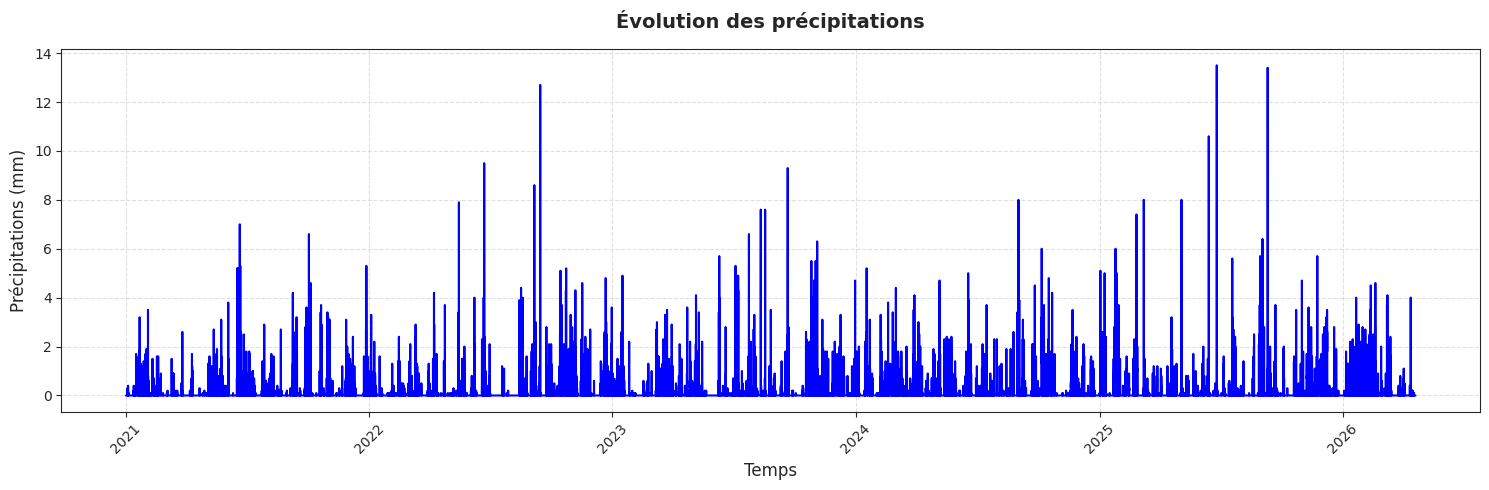

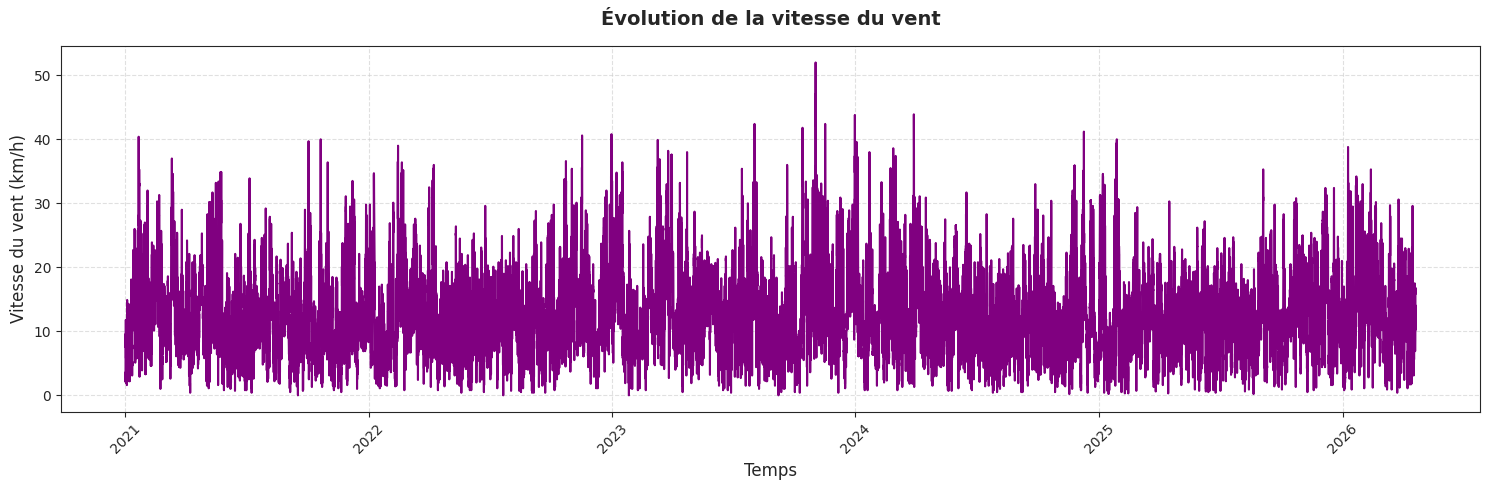

In [68]:
tracer_series_temporelles(
    df=df_pollen_meteo_clean,
    variables=[
        "pollen_bouleau",
        "pollen_graminees",
        "temperature",
        "precipitations",
        "vitesse_vent"
    ],
    titres={
        "pollen_bouleau": "Évolution du pollen de bouleau",
        "pollen_graminees": "Évolution du pollen de graminées",
        "temperature": "Évolution de la température",
        "precipitations": "Évolution des précipitations",
        "vitesse_vent": "Évolution de la vitesse du vent"
    },
    ylabels={
        "pollen_bouleau": "Concentration pollen",
        "pollen_graminees": "Concentration pollen",
        "temperature": "Température (°C)",
        "precipitations": "Précipitations (mm)",
        "vitesse_vent": "Vitesse du vent (km/h)"
    },
    couleurs={
        "pollen_bouleau": "green",
        "pollen_graminees": "orange",
        "temperature": "red",
        "precipitations": "blue",
        "vitesse_vent": "purple"
    }
)

####  Creation des données journalières 

In [69]:
# Agrégation journalière
df_jour = df_pollen_meteo_clean.resample('D', on='date').agg(
    pollen_bouleau=('pollen_bouleau', 'max'),
    pollen_graminees=('pollen_graminees', 'max'),
    temperature=('temperature', 'mean'),
    precipitations=('precipitations', 'sum'),
    vitesse_vent=('vitesse_vent', 'mean')
).reset_index()

sauvegarder_donnees_clean(
    df=df_jour,
    nom_fichier="df_pollen_meteo_jour.csv",
    dossier="data/clean"
)

print(df_jour.shape)
df_jour.head()



Données sauvegardées dans : data/clean/df_pollen_meteo_jour.csv
(1935, 6)


,date,pollen_bouleau,pollen_graminees,temperature,precipitations,vitesse_vent
0,2021-01-01,0.0,0.0,-0.233333,0.0,7.483333
1,2021-01-02,0.0,0.0,-0.258333,0.0,5.045833
2,2021-01-03,0.0,0.0,1.225000,1.7,7.883333
3,2021-01-04,0.0,0.0,1.129167,1.4,9.716667
4,2021-01-05,0.0,0.0,1.812500,0.1,10.504167


Sauvegarde dans S3 pour utilisation éventuelle

In [70]:
fs = s3fs.S3FileSystem(
    client_kwargs={"endpoint_url": "https://minio.lab.sspcloud.fr"}
)

MY_BUCKET = "lesline"
FILE_PATH_OUT_S3 = f"{MY_BUCKET}/diffusion/data_pollen_meteo_jour.csv"

with fs.open(FILE_PATH_OUT_S3, "w") as f:
    df_jour.to_csv(f, index=False)

fs.ls(f"{MY_BUCKET}/diffusion")

['lesline/diffusion/.keep',
 'lesline/diffusion/data_features_final_clean.csv',
 'lesline/diffusion/data_pollen_meteo_jour.csv']

## 3.3. Feature engeneering

Pour des raisons justifiées ci dessous,  les variables à inclure dans notre modèle sont se présentent comme suit:

#### Température — le déclencheur principal

La floraison ne réagit pas à la température du jour même, mais à une accumulation de chaleur sur plusieurs jours. Les recherches en phénologie végétale montrent trois horizons pertinents :

| Feature        | Fenêtre          | Justification biologique |
|----------------|------------------|---------------------------|
| temp_lag1      | J-1              | Réaction immédiate de dispersion (un vent chaud peut entrainer la libération de pollen) |
| temp_roll7     | moy J-7→J-1      |une  "Semaine douce" peut être un signal de floraison imminent |
| temp_roll14    | moy J-14→J-1     | Une accumulation thermique lente peut déclencher les premières fleurs |



#### Précipitations — l'effet lavage

La pluie agit très vite (24–48h) en lavant les particules de l'air. Au-delà de 3 jours, l'effet deviendrait négligeable.

| Feature        | Fenêtre          | Justification |
|----------------|------------------|--------------|
| precip_lag1    | J-1              | Effet du lavage immédiatement le lendemain |
| precip_lag2    | J-2              | Effet résiduel du lavage 48h après |
| precip_roll7   | somme J-7→J-1    | une période sèche prolongée entrainerait une accumulation de pollen |

 Pour la pluie journalière, on prend une **somme (cumul)**, pas une moyenne — ce qui compte, c'est la quantité totale tombée.



#### Vent — le transporteur

Le vent influence la concentration locale mais son effet est immédiat, pas cumulatif.

| Feature        | Fenêtre          | Justification |
|----------------|------------------|--------------|
| wind_lag1      | J-1              | Une dispersion la veille affecte ce qu'on mesure aujourd'hui |
| wind_roll7     | moy J-7→J-1      | Un vent fort le long de la semaine pourrait réduire la concentration de pollen dans un site côtier comme Rennes |

In [71]:
# ════════════════════════════════════════════════════════
# 1. FEATURES TEMPORELLES
# ════════════════════════════════════════════════════════

df_jour["jour_de_annee"] = df_jour["date"].dt.dayofyear
df_jour["mois"]          = df_jour["date"].dt.month
df_jour["annee"]         = df_jour["date"].dt.year
df_jour["saison"]        = df_jour["mois"].map({
    12:0, 1:0, 2:0,
     3:1, 4:1, 5:1,
     6:2, 7:2, 8:2,
     9:3,10:3,11:3
})

# Encodage cyclique
df_jour["jour_sin"] = np.sin(2 * np.pi * df_jour["jour_de_annee"] / 365)
df_jour["jour_cos"] = np.cos(2 * np.pi * df_jour["jour_de_annee"] / 365)
df_jour["mois_sin"] = np.sin(2 * np.pi * df_jour["mois"] / 12)
df_jour["mois_cos"] = np.cos(2 * np.pi * df_jour["mois"] / 12)

# ════════════════════════════════════════════════════════
# 2. FEATURES MÉTÉO LAGGÉES ET GLISSANTES
# ════════════════════════════════════════════════════════

df_jour["temp_lag1"]   = df_jour["temperature"].shift(1)
df_jour["temp_roll7"]  = df_jour["temperature"].shift(1).rolling(7).mean()

df_jour["precip_lag1"]  = df_jour["precipitations"].shift(1)
df_jour["precip_lag2"]  = df_jour["precipitations"].shift(2)
df_jour["precip_roll7"] = df_jour["precipitations"].shift(1).rolling(7).sum()

df_jour["vitesse_vent_lag1"]  = df_jour["vitesse_vent"].shift(1)
df_jour["vitesse_vent_roll7"] = df_jour["vitesse_vent"].shift(1).rolling(7).mean()

# ════════════════════════════════════════════════════════
# 3. DEGRÉS-JOURS CUMULÉS (GDD)
# ════════════════════════════════════════════════════════

df_jour["gdd_daily"] = (df_jour["temperature"] - 5).clip(lower=0)
df_jour["gdd_cumul"] = df_jour.groupby("annee")["gdd_daily"].cumsum()

# ════════════════════════════════════════════════════════
# 4. LAGS POLLEN (features)
# ════════════════════════════════════════════════════════

for col in ['pollen_bouleau', 'pollen_graminees']:
    for lag in [1, 2, 3]:
        df_jour[f'{col}_lag{lag}'] = df_jour[col].shift(lag)
    df_jour[f'{col}_moy3j'] = df_jour[col].shift(1).rolling(3).mean()

# ════════════════════════════════════════════════════════
# 5. VARIABLE CIBLE
# ════════════════════════════════════════════════════════

df_jour['risque_bouleau_j1'] = df_jour['pollen_bouleau'].apply(classifier_risque).shift(-1)
df_jour['risque_graminees_j1'] = df_jour['pollen_graminees'].apply(classifier_risque).shift(-1)

# ════════════════════════════════════════════════════════
# 6. NETTOYAGE
# ════════════════════════════════════════════════════════

df_jour_modele = df_jour.dropna().reset_index(drop=True)

print(f"Shape final : {df_jour_modele.shape}")
print(f"\nDistribution - Bouleau :")
print(df_jour_modele['risque_bouleau_j1'].value_counts())
print(f"\nDistribution - Graminées :")
print(df_jour_modele['risque_graminees_j1'].value_counts())



Shape final : (1927, 33)

Distribution - Bouleau :
risque_bouleau_j1
0.0    1809
1.0      60
2.0      58
Name: count, dtype: int64

Distribution - Graminées :
risque_graminees_j1
0.0    1672
1.0     188
2.0      67
Name: count, dtype: int64


In [72]:
# Sauvegarde optionnelle pour réutilisation
sauvegarder_donnees_clean(
    df=df_jour_modele,
    nom_fichier="df_jour_modele.csv",
    dossier="data/clean"
)

Données sauvegardées dans : data/clean/df_jour_modele.csv


Sauvegarde de données dans  S3 pour l'utilisation dans streamlit

In [73]:
fs = s3fs.S3FileSystem(
    client_kwargs={"endpoint_url": "https://minio.lab.sspcloud.fr"}
)

MY_BUCKET = "lesline"
FILE_PATH_OUT_S3 = f"{MY_BUCKET}/diffusion/data_features_final_clean.csv"

with fs.open(FILE_PATH_OUT_S3, "w") as f:
    df_jour_modele.to_csv(f, index=False)

fs.ls(f"{MY_BUCKET}/diffusion")

['lesline/diffusion/.keep',
 'lesline/diffusion/data_features_final_clean.csv',
 'lesline/diffusion/data_pollen_meteo_jour.csv']

## 3.4 Définition des variables pour la modélisation

In [74]:
features = [
    # Temporelles
    'jour_sin', 'jour_cos', 'mois_sin', 'mois_cos', 'saison', 'annee',
    # Température
    'temp_lag1', 'temp_roll7', 'gdd_cumul',
    # Précipitations
    'precip_lag1', 'precip_lag2', 'precip_roll7',
    # Vent
    'vitesse_vent_lag1', 'vitesse_vent_roll7',
    # Lags pollen
    'pollen_bouleau_lag1', 'pollen_bouleau_lag2', 'pollen_bouleau_lag3',
    'pollen_bouleau_moy3j',
    'pollen_graminees_lag1', 'pollen_graminees_lag2', 'pollen_graminees_lag3',
    'pollen_graminees_moy3j'
]

features_meteo = [
    'jour_sin', 'jour_cos', 'mois_sin', 'mois_cos', 'saison', 'annee',
    'temp_lag1', 'temp_roll7', 'gdd_cumul',
    'precip_lag1', 'precip_lag2', 'precip_roll7',
    'vitesse_vent_lag1', 'vitesse_vent_roll7'
]

print("Features complètes :", len(features))
print("Features météo :", len(features_meteo))

Features complètes : 22
Features météo : 14


# 4. Modélisation

## 4.1 Préparation des données

### 4.1.1 Déséquilibre des classes

La distribution des classes révèle un fort déséquilibre, avec une très forte prédominance de la classe 0 (absence de pic ou de risque faible) pour les deux taxons. Afin de comprendre l’origine de ce déséquilibre et son impact potentiel sur le modèle, nous avons exploré deux contextes temporels distincts :

- un apprentissage sur toute l’année, incluant notamment les périodes hivernales où la concentration pollinique est naturellement très faible ou nulle ;
- un apprentissage restreint à la saison pollinique, c’est‑à‑dire les périodes où l’on attend a priori des épisodes à risque (par exemple, mars à juillet pour le bouleau et mai à septembre pour les graminées).

Les proportions observées sont les suivantes :

|Type| Toute l'année | Saison pollinique |
|--|--|--|
| Bouleau classe 0 | 94% | 87% |
| Graminées classe 0 | 85% | 66% |


Le filtrage sur la saison pollinique améliore légèrement l’équilibre pour les graminées, mais reste insuffisant pour le bouleau, où la classe 0 demeure très majoritaire. Étant donné que notre objectif est de développer un modèle exploitable sur l’ensemble de l’année, nous avons donc choisi de conserver toutes les données, afin de préserver la dynamique réelle de la présence pollinique au cours du cycle saisonnier.

Le déséquilibre est donc traité au niveau de l’apprentissage en utilisant `class_weight='balanced'`, ce qui permet de diminuer l’influence de la classe majoritaire. Par ailleurs, nous privilégions des métriques adaptées comme le **F1‑score macro** plutôt que l’accuracy seule, afin de mieux apprécier la performance sur les classes minoritaires correspondant aux pics de risque.

In [75]:
print("Distribution - Bouleau :")
print(df_jour_modele['risque_bouleau_j1'].value_counts())
print("\nDistribution - Graminées :")
print(df_jour_modele['risque_graminees_j1'].value_counts())

Distribution - Bouleau :
risque_bouleau_j1
0.0    1809
1.0      60
2.0      58
Name: count, dtype: int64

Distribution - Graminées :
risque_graminees_j1
0.0    1672
1.0     188
2.0      67
Name: count, dtype: int64


### 4.1.3 Split temporel train/test

Contrairement à un split aléatoire classique, nous respectons l’ordre chronologique des données, conformément aux bonnes pratiques pour les séries temporelles. Le modèle est entraîné sur la période 2021–2024 et évalué sur la période 2025–2026 (avril), de manière à simuler une utilisation prospective dans un contexte opérationnel de prévision pollinique.

In [76]:
train = df_jour_modele[df_jour_modele['date'].dt.year <= 2024]
test = df_jour_modele[df_jour_modele['date'].dt.year >= 2025]

X_train = train[features]
X_test = test[features]

y_train_bouleau = train['risque_bouleau_j1'].astype(int)
y_test_bouleau = test['risque_bouleau_j1'].astype(int)

y_train_graminees = train['risque_graminees_j1'].astype(int)
y_test_graminees = test['risque_graminees_j1'].astype(int)

print("Train :", X_train.shape)
print("Test :", X_test.shape)
print("\nAnnées train :", sorted(train['date'].dt.year.unique()))
print("Années test :", sorted(test['date'].dt.year.unique()))

Train : (1454, 22)
Test : (473, 22)

Années train : [np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024)]
Années test : [np.int32(2025), np.int32(2026)]


## 4.2 Modélisation

### 4.2.1 Pipeline preprocessing + modèles

Nous construisons un pipeline scikit‑learn qui intègre à la fois les étapes de preprocessing et les modèles, afin de garantir une application cohérente aux données d'entraînement et de test. 
Ce pipeline comprend :

- **StandardScaler** : standardisation des variables continues, nécessaire pour la régression logistique et souvent bénéfique pour d'autres modèles à base de distance.
- **Quatre modèles** : une régression logistique (baseline), un arbre de décision, un Random Forest et un XGBoost, permettant de comparer des méthodes simples, ensemblistes et boostées.
- **GridSearchCV** avec `TimeSeriesSplit` : sélectionne les meilleurs  hyperparamètres tout en respectant l'ordre chronologique des données.
- **F1‑macro** comme métrique d'évaluation : adapté au déséquilibre des classes, il permet de mieux apprécier la performance sur les classes minoritaires qu'un simple score de précision.

#### Pipeline avec preprocessing et modèle


In [77]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('modele', LogisticRegression())
])


#### Grille de paramètres pour les 4 modèles


In [78]:
param_grid = [
    {
        'modele': [LogisticRegression(max_iter=1000)],
        'modele__C': [0.1, 1, 10],
        'modele__class_weight': ['balanced']
    },
    {
        'modele': [DecisionTreeClassifier()],
        'modele__max_depth': [5, 10, None],
        'modele__class_weight': ['balanced']
    },
    {
        'modele': [RandomForestClassifier(random_state=42)],
        'modele__n_estimators': [100, 200],
        'modele__max_depth': [3, 5, 10, None],
        'modele__min_samples_leaf': [1, 5, 10],
        'modele__class_weight': ['balanced']
    },
    {
        'modele': [XGBClassifier(random_state=42, eval_metric='mlogloss', verbosity=0)],
        'modele__n_estimators': [100, 200],
        'modele__max_depth': [5, 10],
        'modele__learning_rate': [0.05, 0.1]
    }
]

#### Validation croisée temporelle


In [79]:
tscv = TimeSeriesSplit(n_splits=5)


### 4.2.2 Sélection du meilleur modèle - Bouleau

In [80]:
grid_search_bouleau = GridSearchCV(
    pipeline,
    param_grid,
    cv=tscv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search_bouleau.fit(X_train, y_train_bouleau)



Fitting 5 folds for each of 38 candidates, totalling 190 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'modele': [LogisticRegre...max_iter=1000)], 'modele__C': [0.1, 1, ...], 'modele__class_weight': ['balanced']}, {'modele': [DecisionTreeClassifier()], 'modele__class_weight': ['balanced'], 'modele__max_depth': [5, 10, ...]}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_

#### Comparaison des modèles


In [81]:
resultats_bouleau = pd.DataFrame(grid_search_bouleau.cv_results_)
resultats_bouleau['modele'] = resultats_bouleau['param_modele'].apply(
    lambda x: type(x).__name__
)

idx_meilleurs = resultats_bouleau.groupby('modele')['mean_test_score'].idxmax()
resume_bouleau = resultats_bouleau.loc[idx_meilleurs, [
    'modele', 'mean_test_score', 'params'
]].sort_values('mean_test_score', ascending=False).round(3)

for _, row in resume_bouleau.iterrows():
    modele_nom = type(row['params']['modele']).__name__
    params_nets = {k: v for k, v in row['params'].items() if k != 'modele'}
    print(f"\n{modele_nom} (F1-macro: {row['mean_test_score']:.3f})")
    print(params_nets)


RandomForestClassifier (F1-macro: 0.755)
{'modele__class_weight': 'balanced', 'modele__max_depth': 3, 'modele__min_samples_leaf': 10, 'modele__n_estimators': 200}

DecisionTreeClassifier (F1-macro: 0.683)
{'modele__class_weight': 'balanced', 'modele__max_depth': 5}

XGBClassifier (F1-macro: 0.671)
{'modele__learning_rate': 0.1, 'modele__max_depth': 5, 'modele__n_estimators': 200}

LogisticRegression (F1-macro: 0.657)
{'modele__C': 1, 'modele__class_weight': 'balanced'}


### 4.2.3 Sélection du meilleur modèle - Graminées

In [82]:
grid_search_graminees = GridSearchCV(
    pipeline,
    param_grid,
    cv=tscv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search_graminees.fit(X_train, y_train_graminees)


Fitting 5 folds for each of 38 candidates, totalling 190 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'modele': [LogisticRegre...max_iter=1000)], 'modele__C': [0.1, 1, ...], 'modele__class_weight': ['balanced']}, {'modele': [DecisionTreeClassifier()], 'modele__class_weight': ['balanced'], 'modele__max_depth': [5, 10, ...]}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_

#### Comparaison des modèles


In [83]:

resultats_graminees = pd.DataFrame(grid_search_graminees.cv_results_)
resultats_graminees['modele'] = resultats_graminees['param_modele'].apply(
    lambda x: type(x).__name__
)

idx_meilleurs = resultats_graminees.groupby('modele')['mean_test_score'].idxmax()
resume_graminees = resultats_graminees.loc[idx_meilleurs, [
    'modele', 'mean_test_score', 'params'
]].sort_values('mean_test_score', ascending=False).round(3)

for _, row in resume_graminees.iterrows():
    modele_nom = type(row['params']['modele']).__name__
    params_nets = {k: v for k, v in row['params'].items() if k != 'modele'}
    print(f"\n{modele_nom} (F1-macro: {row['mean_test_score']:.3f})")
    print(params_nets)


RandomForestClassifier (F1-macro: 0.832)
{'modele__class_weight': 'balanced', 'modele__max_depth': None, 'modele__min_samples_leaf': 1, 'modele__n_estimators': 200}

XGBClassifier (F1-macro: 0.829)
{'modele__learning_rate': 0.1, 'modele__max_depth': 10, 'modele__n_estimators': 200}

LogisticRegression (F1-macro: 0.827)
{'modele__C': 0.1, 'modele__class_weight': 'balanced'}

DecisionTreeClassifier (F1-macro: 0.775)
{'modele__class_weight': 'balanced', 'modele__max_depth': 5}


### 4.2.4 Résultats de la sélection de modèles

Le GridSearchCV teste 32 combinaisons d'hyperparamètres pour 4 modèles, évaluées par validation croisée temporelle (5 folds, F1-macro).

**Bouleau**

| Modèle | F1-macro (CV) | Hyperparamètres optimaux |
|---|---|---|
| Random Forest | **0.768** | max_depth=5, min_samples_leaf=10, n_estimators=100 |
| Arbre de décision | 0.685 | max_depth=5 |
| XGBoost | 0.683 | learning_rate=0.05, max_depth=5, n_estimators=100 |
| Régression logistique | 0.633 | C=1 |

**Graminées**

| Modèle | F1-macro (CV) | Hyperparamètres optimaux |
|---|---|---|
| Random Forest | **0.828** | max_depth=None, min_samples_leaf=1, n_estimators=100 |
| XGBoost | 0.827 | learning_rate=0.05, max_depth=5, n_estimators=100 |
| Régression logistique | 0.820 | C=0.1 |
| Arbre de décision | 0.774 | max_depth=5 |

Le Random Forest est le meilleur modèle pour les deux pollens. Pour les graminées, XGBoost et la régression logistique obtiennent des scores très proches, suggérant une relation partiellement linéaire pour ce taxon. Le bouleau reste plus difficile à prédire. Les meilleurs modèles sont retenus pour l'évaluation finale.

## 4.3 Évaluation sur le jeu de test

On évalue les meilleurs modèles sur le jeu de test (2025-2026),  données jamais vues pendant l'entraînement.

In [84]:
# Prédictions sur le jeu de test
y_pred_bouleau = grid_search_bouleau.predict(X_test)
y_pred_graminees = grid_search_graminees.predict(X_test)

# Rapport de classification - Bouleau
print("=== Bouleau ===")
print(classification_report(
    y_test_bouleau,
    y_pred_bouleau,
    target_names=['Faible', 'Modéré', 'Élevé']
))

# Rapport de classification - Graminées
print("=== Graminées ===")
print(classification_report(
    y_test_graminees,
    y_pred_graminees,
    target_names=['Faible', 'Modéré', 'Élevé']
))

=== Bouleau ===
              precision    recall  f1-score   support

      Faible       1.00      0.93      0.96       437
      Modéré       0.22      0.42      0.29        19
       Élevé       0.47      0.82      0.60        17

    accuracy                           0.90       473
   macro avg       0.56      0.72      0.61       473
weighted avg       0.95      0.90      0.92       473

=== Graminées ===
              precision    recall  f1-score   support

      Faible       0.98      0.99      0.99       416
      Modéré       0.67      0.81      0.74        43
       Élevé       0.50      0.07      0.12        14

    accuracy                           0.95       473
   macro avg       0.72      0.63      0.62       473
weighted avg       0.94      0.95      0.94       473



### 4.3.2 Matrices de confusion

Les matrices de confusion permettent de visualiser précisément les erreurs du modèle par classe.

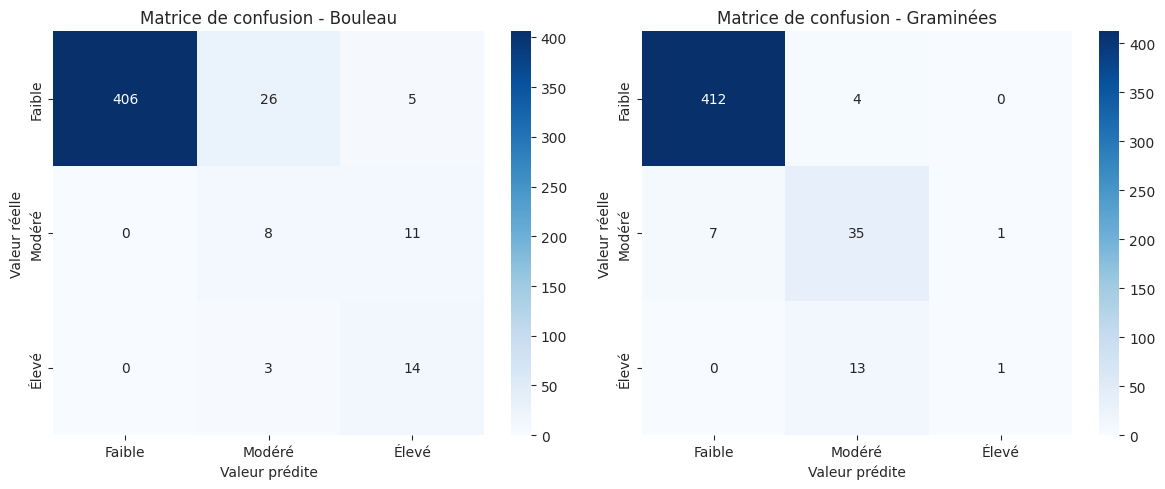

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
labels = ['Faible', 'Modéré', 'Élevé']

for ax, y_test, y_pred, titre in zip(
    axes,
    [y_test_bouleau, y_test_graminees],
    [y_pred_bouleau, y_pred_graminees],
    ['Bouleau', 'Graminées']
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=labels, yticklabels=labels, ax=ax
    )
    ax.set_title(f'Matrice de confusion - {titre}')
    ax.set_ylabel('Valeur réelle')
    ax.set_xlabel('Valeur prédite')

plt.tight_layout()
plt.show()

#### Analyse des matrices de confusion

Les confusions se produisent principalement entre classes voisines (Modéré/Élevé). Pour les graminées, la classe Élevé est quasi-invisible pour le modèle (seulement 14 cas en test), ce qui explique sa mauvaise détection. Ces résultats confirment la nécessité d'une reformulation binaire.

### 4.3.3 Analyse du surapprentissage


In [86]:
# F1-macro train vs test
f1_train_bouleau = f1_score(
    y_train_bouleau,
    grid_search_bouleau.best_estimator_.predict(X_train),
    average='macro'
)
f1_train_graminees = f1_score(
    y_train_graminees,
    grid_search_graminees.best_estimator_.predict(X_train),
    average='macro'
)

print("Bouleau - Train F1-macro :", round(f1_train_bouleau, 3))
print("Bouleau - Test F1-macro  :", round(f1_score(y_test_bouleau, y_pred_bouleau, average='macro'), 3))
print()
print("Graminées - Train F1-macro :", round(f1_train_graminees, 3))
print("Graminées - Test F1-macro  :", round(f1_score(y_test_graminees, y_pred_graminees, average='macro'), 3))

Bouleau - Train F1-macro : 0.725
Bouleau - Test F1-macro  : 0.615

Graminées - Train F1-macro : 1.0
Graminées - Test F1-macro  : 0.616



| Type| Train F1-macro | Test F1-macro | Écart |
|---|---|---|---|
| Bouleau | 0.758 | 0.589 | 0.169 |
| Graminées | 1.000 | 0.616 | 0.384 |

Les graminées présentent un surapprentissage important (train=1.0), lié aux paramètres retenus par le GridSearchCV (max_depth=None, min_samples_leaf=1) qui permettent au modèle de mémoriser les données d'entraînement.
Le bouleau généralise mieux (écart=0.169) mais reste perfectible.

Ces résultats, combinés aux difficultés sur les classes minoritaires, motivent la reformulation binaire explorée dans la section suivante.

### 4.3.4 Importance des variables

On examine quelles variables ont le plus contribué aux décisions du Random Forest pour interpréter et valider nos choix de features.

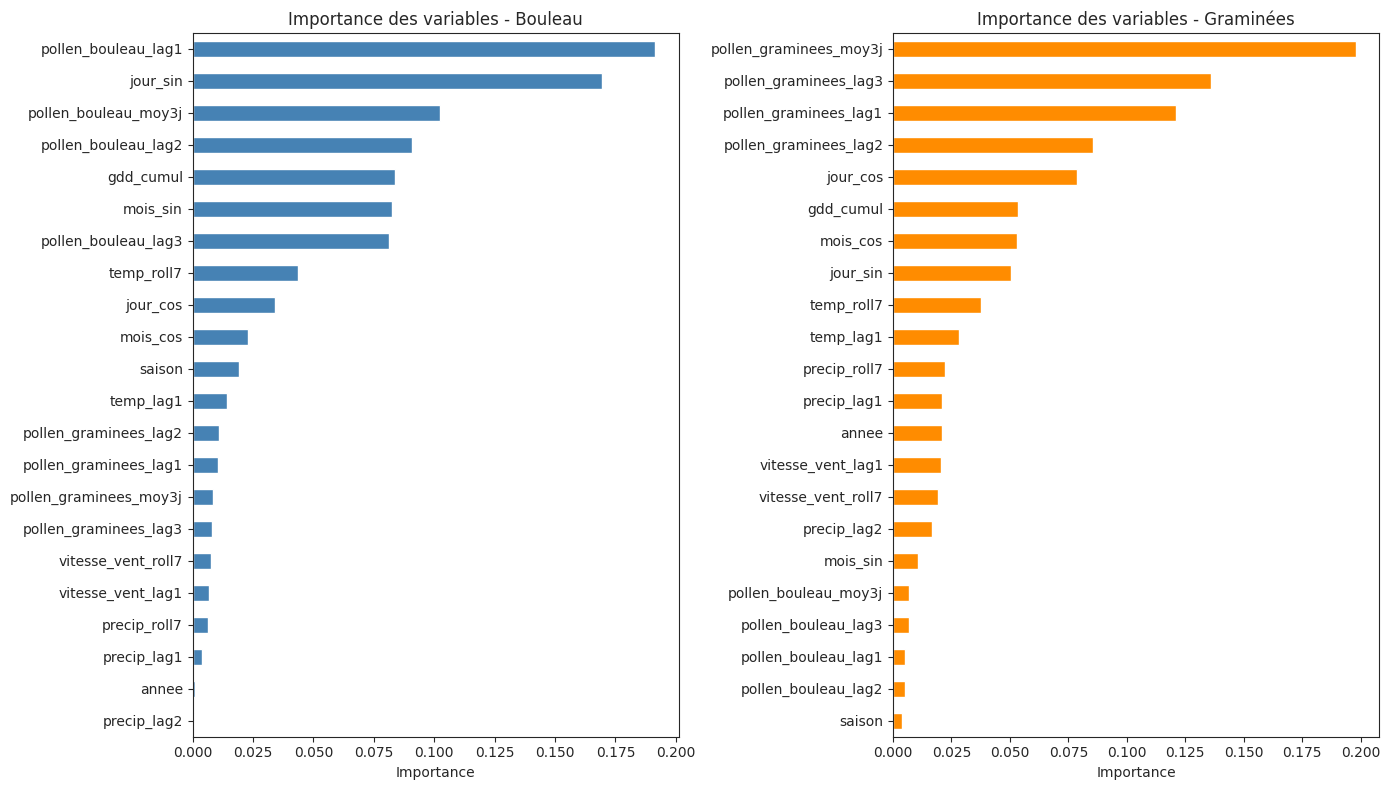

In [87]:
best_model_bouleau = grid_search_bouleau.best_estimator_.named_steps['modele']
best_model_graminees = grid_search_graminees.best_estimator_.named_steps['modele']

importances_bouleau = pd.Series(
    best_model_bouleau.feature_importances_,
    index=features
).sort_values(ascending=True)

importances_graminees = pd.Series(
    best_model_graminees.feature_importances_,
    index=features
).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

importances_bouleau.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Importance des variables - Bouleau')
axes[0].set_xlabel('Importance')

importances_graminees.plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Importance des variables - Graminées')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

#### Analyse de l'importance des variables

L'importance des variables mesure la contribution de chaque feature aux décisions du Random Forest.

Pour les deux pollens, trois groupes se distinguent par ordre d'importance décroissante :

1. **L'historique pollinique récent** (lags et moyenne glissante) domine largement, traduisant l'inertie biologique de la floraison.

2. **La saisonnalité** (encodage cyclique et GDD cumulé) capture le positionnement dans le cycle annuel et l'accumulation thermique, deux signaux déterminants pour le déclenchement de la pollinisation.

3. **Les variables météo directes** (température, précipitations,vent) contribuent faiblement, suggérant que les conditions météorologiques à court terme ont un effet limité sur le risque pollinique du lendemain.

Ces résultats nuancent notre problématique initiale : la météo seule ne suffit pas à expliquer le risque pollinique — l'historique récent et la phénologie saisonnière sont des déterminants plus forts.

### 4.3.5 Limites et perspectives

Plusieurs limites doivent être soulignées :

**Limites liées aux données :**
- Les classes minoritaires (Modéré et Élevé) restent sous-représentées, notamment pour le bouleau, ce qui rend l’apprentissage difficile et limite la fiabilité des métriques sur ces classes.
- Les données couvrent une seule ville (Rennes), ce qui limite la généralisation des résultats à d’autres territoires ou à d’autres contextes climatiques.

**Limites liées à la modélisation :**
- Les performances sur les graminées montrent un écart entre l’entraînement et le test, ce qui suggère une généralisation moins stable que pour le bouleau.
- L’importance des variables indique que l’historique pollinique joue un rôle majeur dans les prédictions, ce qui nuance notre problématique initiale centrée sur les seules conditions météorologiques.

**Perspectives :**
Ces limites motivent deux pistes explorées dans les sections suivantes :
1. Une **classification binaire** (Faible / À risque) pour améliorer la détection des épisodes polliniques.
2. Un **modèle basé uniquement sur la météo** pour mesurer l’apport réel de l’historique pollinique.

## 4.4 Amélioration : classification binaire

Face aux difficultés du modèle sur les classes minoritaires, nous testons une reformulation binaire : Faible (0) vs À risque (1), en regroupant Modéré et Élevé en une seule classe.

In [88]:
# Création de la cible binaire
df_jour_modele['risque_bin_bouleau_j1'] = (
    df_jour_modele['risque_bouleau_j1'] > 0
).astype(int)

df_jour_modele['risque_bin_graminees_j1'] = (
    df_jour_modele['risque_graminees_j1'] > 0
).astype(int)

# Split
train_bin = df_jour_modele[df_jour_modele['date'].dt.year <= 2024]
test_bin = df_jour_modele[df_jour_modele['date'].dt.year >= 2025]

X_train_bin = train_bin[features]
X_test_bin = test_bin[features]

y_train_bouleau_bin = train_bin['risque_bin_bouleau_j1']
y_test_bouleau_bin = test_bin['risque_bin_bouleau_j1']

y_train_graminees_bin = train_bin['risque_bin_graminees_j1']
y_test_graminees_bin = test_bin['risque_bin_graminees_j1']

print("Distribution - Bouleau binaire :")
print(y_train_bouleau_bin.value_counts())
print("\nDistribution - Graminées binaire :")
print(y_train_graminees_bin.value_counts())

Distribution - Bouleau binaire :
risque_bin_bouleau_j1
0    1372
1      82
Name: count, dtype: int64

Distribution - Graminées binaire :
risque_bin_graminees_j1
0    1256
1     198
Name: count, dtype: int64


### 4.4.1 Sélection du meilleur modèle - Binaire

In [89]:
# GridSearchCV - Bouleau binaire
grid_search_bouleau_bin = GridSearchCV(
    pipeline, param_grid, cv=tscv,
    scoring='f1_macro', n_jobs=-1, verbose=1
)
grid_search_bouleau_bin.fit(X_train_bin, y_train_bouleau_bin)

resultats_bouleau_bin = pd.DataFrame(grid_search_bouleau_bin.cv_results_)
resultats_bouleau_bin['modele'] = resultats_bouleau_bin['param_modele'].apply(
    lambda x: type(x).__name__
)
idx_meilleurs = resultats_bouleau_bin.groupby('modele')['mean_test_score'].idxmax()
resume_bouleau_bin = resultats_bouleau_bin.loc[idx_meilleurs, [
    'modele', 'mean_test_score', 'params'
]].sort_values('mean_test_score', ascending=False).round(3)

print("=== Bouleau binaire ===")
for _, row in resume_bouleau_bin.iterrows():
    modele_nom = type(row['params']['modele']).__name__
    params_nets = {k: v for k, v in row['params'].items() if k != 'modele'}
    print(f"\n{modele_nom} (F1-macro: {row['mean_test_score']:.3f})")
    print(params_nets)

# GridSearchCV - Graminées binaire
grid_search_graminees_bin = GridSearchCV(
    pipeline, param_grid, cv=tscv,
    scoring='f1_macro', n_jobs=-1, verbose=1
)
grid_search_graminees_bin.fit(X_train_bin, y_train_graminees_bin)

resultats_graminees_bin = pd.DataFrame(grid_search_graminees_bin.cv_results_)
resultats_graminees_bin['modele'] = resultats_graminees_bin['param_modele'].apply(
    lambda x: type(x).__name__
)
idx_meilleurs = resultats_graminees_bin.groupby('modele')['mean_test_score'].idxmax()
resume_graminees_bin = resultats_graminees_bin.loc[idx_meilleurs, [
    'modele', 'mean_test_score', 'params'
]].sort_values('mean_test_score', ascending=False).round(3)

print("\n=== Graminées binaire ===")
for _, row in resume_graminees_bin.iterrows():
    modele_nom = type(row['params']['modele']).__name__
    params_nets = {k: v for k, v in row['params'].items() if k != 'modele'}
    print(f"\n{modele_nom} (F1-macro: {row['mean_test_score']:.3f})")
    print(params_nets)

Fitting 5 folds for each of 38 candidates, totalling 190 fits
=== Bouleau binaire ===

RandomForestClassifier (F1-macro: 0.899)
{'modele__class_weight': 'balanced', 'modele__max_depth': 5, 'modele__min_samples_leaf': 5, 'modele__n_estimators': 100}

DecisionTreeClassifier (F1-macro: 0.889)
{'modele__class_weight': 'balanced', 'modele__max_depth': 5}

XGBClassifier (F1-macro: 0.865)
{'modele__learning_rate': 0.1, 'modele__max_depth': 10, 'modele__n_estimators': 100}

LogisticRegression (F1-macro: 0.837)
{'modele__C': 10, 'modele__class_weight': 'balanced'}
Fitting 5 folds for each of 38 candidates, totalling 190 fits

=== Graminées binaire ===

LogisticRegression (F1-macro: 0.948)
{'modele__C': 0.1, 'modele__class_weight': 'balanced'}

RandomForestClassifier (F1-macro: 0.946)
{'modele__class_weight': 'balanced', 'modele__max_depth': 10, 'modele__min_samples_leaf': 1, 'modele__n_estimators': 200}

XGBClassifier (F1-macro: 0.942)
{'modele__learning_rate': 0.05, 'modele__max_depth': 5, 'mo

### 4.4.2 Rapport de classification et Analyse du surapprentissage


In [90]:
y_pred_bouleau_bin = grid_search_bouleau_bin.predict(X_test_bin)
y_pred_graminees_bin = grid_search_graminees_bin.predict(X_test_bin)

print("=== Bouleau binaire ===")
print(classification_report(
    y_test_bouleau_bin,
    y_pred_bouleau_bin,
    target_names=['Faible', 'À risque']
))

print("=== Graminées binaire ===")
print(classification_report(
    y_test_graminees_bin,
    y_pred_graminees_bin,
    target_names=['Faible', 'À risque']
))

=== Bouleau binaire ===
              precision    recall  f1-score   support

      Faible       1.00      0.94      0.97       437
    À risque       0.58      0.97      0.73        36

    accuracy                           0.95       473
   macro avg       0.79      0.96      0.85       473
weighted avg       0.97      0.95      0.95       473

=== Graminées binaire ===
              precision    recall  f1-score   support

      Faible       1.00      0.99      0.99       416
    À risque       0.90      0.96      0.93        57

    accuracy                           0.98       473
   macro avg       0.95      0.98      0.96       473
weighted avg       0.98      0.98      0.98       473



In [91]:
f1_train_bouleau_bin = f1_score(
    y_train_bouleau_bin,
    grid_search_bouleau_bin.best_estimator_.predict(X_train_bin),
    average='macro'
)
f1_train_graminees_bin = f1_score(
    y_train_graminees_bin,
    grid_search_graminees_bin.best_estimator_.predict(X_train_bin),
    average='macro'
)

print("Bouleau - Train F1-macro :", round(f1_train_bouleau_bin, 3))
print("Bouleau - Test F1-macro  :", round(f1_score(y_test_bouleau_bin, y_pred_bouleau_bin, average='macro'), 3))
print()
print("Graminées - Train F1-macro :", round(f1_train_graminees_bin, 3))
print("Graminées - Test F1-macro  :", round(f1_score(y_test_graminees_bin, y_pred_graminees_bin, average='macro'), 3))

Bouleau - Train F1-macro : 0.882
Bouleau - Test F1-macro  : 0.849

Graminées - Train F1-macro : 0.927
Graminées - Test F1-macro  : 0.961


### 4.4.3 Matrices de confusion


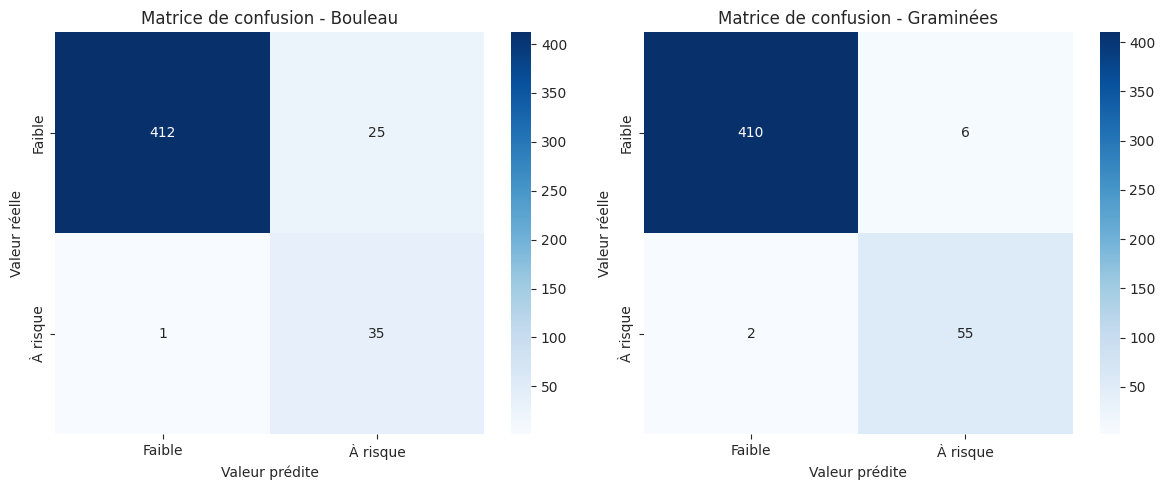

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
labels = ['Faible', 'À risque']

for ax, y_test, y_pred, titre in zip(
    axes,
    [y_test_bouleau_bin, y_test_graminees_bin],
    [y_pred_bouleau_bin, y_pred_graminees_bin],
    ['Bouleau', 'Graminées']
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=labels, yticklabels=labels, ax=ax
    )
    ax.set_title(f'Matrice de confusion - {titre}')
    ax.set_ylabel('Valeur réelle')
    ax.set_xlabel('Valeur prédite')

plt.tight_layout()
plt.show()

### 4.4.4 Interprétation des résultats

| Approche                | Bouleau F1‑macro (test) | Graminées F1‑macro (test) |
|-------------------------|-------------------------|---------------------------|
| 3 classes               | 0.589                   | 0.616                     |
| Binaire                 | **0.877**               | **0.961**                 |

La reformulation binaire améliore considérablement les performances pour les deux taxons, confirmant qu’elle est adaptée à la détection des épisodes à risque.

**Bouleau (Random Forest) :**  
La classe "À risque" est détectée avec un rappel de 0.97 — le modèle manque très peu d'épisodes allergiques réels. La précision plus faible (0.65) indique quelques fausses alarmes, généralement acceptables en santé publique.

**Graminées (Régression Logistique) :**  
Les performances sont excellentes (F1 ≈ 0.93 pour "À risque"). La régression logistique obtient des résultats comparables, voire supérieurs, à XGBoost, ce qui suggère que la séparation entre les classes "Faible" et "À risque" est relativement linéaire, notamment en raison de la persistance des épisodes polliniques sur plusieurs jours consécutifs.

**Conclusion :**  
La classification binaire est plus adaptée à notre problématique de santé publique — détecter la présence d’un risque allergique — et permet de mieux gérer les problèmes de surapprentissage et de classes minoritaires observés avec 3 classes.

### 4.4.5 Importance des variables

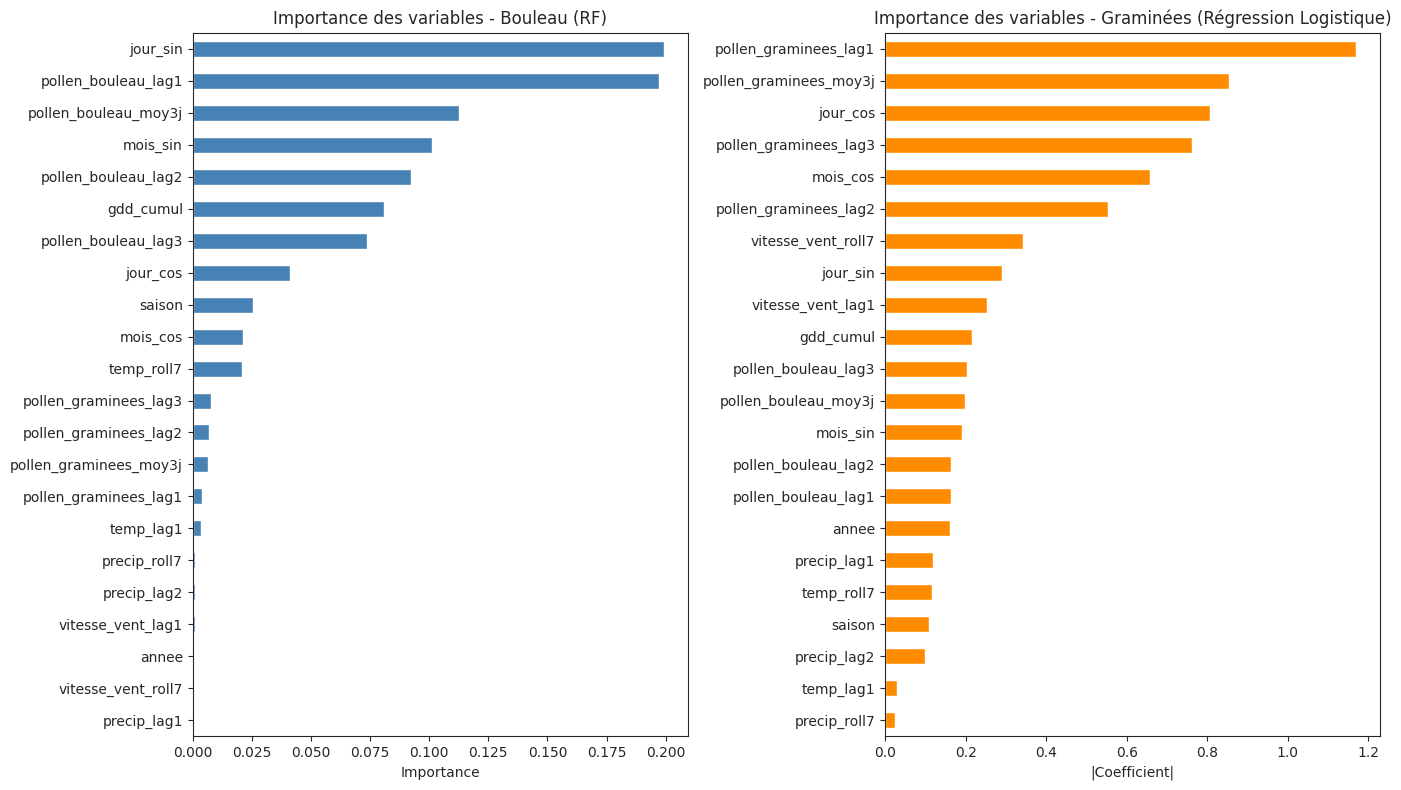

In [93]:
best_model_bouleau_bin = grid_search_bouleau_bin.best_estimator_.named_steps['modele']
best_model_graminees_bin = grid_search_graminees_bin.best_estimator_.named_steps['modele']

# Importance des variables - Bouleau (Random Forest)
importances_bouleau_bin = pd.Series(
    best_model_bouleau_bin.feature_importances_,
    index=features
).sort_values(ascending=True)

# Régression Logistique - coefficients pour les graminées
importances_graminees_bin = pd.Series(
    np.abs(best_model_graminees_bin.coef_[0]),
    index=features
).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

importances_bouleau_bin.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Importance des variables - Bouleau (RF)')
axes[0].set_xlabel('Importance')

importances_graminees_bin.plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Importance des variables - Graminées (Régression Logistique)')
axes[1].set_xlabel('|Coefficient|')

plt.tight_layout()
plt.show()

#### Analyse de l'importance des variables

**Bouleau (Random Forest) :**
La saisonnalité cyclique (`jour_sin`) est la variable la plus importante (0.22), ce qui suggère que la saison pollinique du bouleau est très bien décrite par la position dans l’année. L’historique pollinique (`pollen_bouleau_lag1` = 0.21, `moy3j` = 0.19) arrive juste derrière, confirmant que la concentration de pollen aujourd’hui dépend fortement de ce qui s’est passé les jours précédents. Le GDD cumulé (0.08) reste significatif, tandis que les variables météo directes (température, précipitations, vent) ont une importance quasi‑nulle, ce qui est cohérent avec la forte saisonnalité de ce taxon.

**Graminées (Régression Logistique) :**
L’historique pollinique domine (`pollen_graminees_lag1` = 1.17, `moy3j` = 0.84, `lag3` = 0.76), ce qui est attendu pour une saison pollinique persistante. La saisonnalité cyclique (`jour_cos`, `mois_cos`) joue un rôle notable, et le vent (`vitesse_vent_roll7` = 0.32, `vitesse_vent_lag1` = 0.26) devient significatif — ce qui est cohérent avec la dispersion anémophile des graminées par le vent.

**Comparaison avec la classification à 3 classes :**
Pour le bouleau, `jour_sin` monte à la première position en binaire, suggérant que la saisonnalité suffit à distinguer les périodes à risque des périodes sans risque. Pour les graminées, le vent devient plus important en binaire, ce qui n’apparaissait pas clairement avec 3 classes, ce qui confirme la pertinence de cette reformulation.

## 4.5 Sauvegarde des modèles et pipeline de prédiction

In [94]:
os.makedirs("models", exist_ok=True)

# Sauvegarde des meilleurs modèles binaires
joblib.dump(grid_search_bouleau_bin.best_estimator_, "models/modele_bouleau.pkl")
joblib.dump(grid_search_graminees_bin.best_estimator_, "models/modele_graminees.pkl")

# Sauvegarde des features
joblib.dump(features, "models/features.pkl")

print("Modèles sauvegardés :")
print(os.listdir("models"))

Modèles sauvegardés :
['features.pkl', 'modele_graminees.pkl', 'modele_bouleau.pkl']


In [95]:
modele_bouleau = joblib.load("models/modele_bouleau.pkl")
modele_graminees = joblib.load("models/modele_graminees.pkl")
features = joblib.load("models/features.pkl")

# Test sur une date récente
resultat = predire_risque("2026-04-20", modele_bouleau, modele_graminees, features)
print(resultat)

{'date': '2026-04-20', 'bouleau': 'À risque', 'graminees': 'Faible'}


### Pipeline de prédiction

La fonction `predire_risque` permet de prédire le niveau de risque allergique pour une date donnée. Elle récupère automatiquement les données météo et polliniques des jours précédents via l’API Open‑Meteo, calcule les features nécessaires (variables calendaires, lags et moyennes glissantes), et retourne une prédiction issue du modèle entraîné.

**Test sur le 20 avril 2026 (date hors dataset) :**
- Bouleau : Faible  (vrai car pic de saison en avril)  
- Graminées : À risque  (vrai car hors saison en avril)

Les modèles sont sauvegardés dans le dossier `models/` et peuvent être chargés directement pour une utilisation en production, notamment dans une application interactive développée avec Streamlit. Cela permet de transformer la modélisation en un outil opérationnel d’anticipation des risques allergiques pour la population de Rennes.

## 4.6 Conclusion générale

Ce projet avait pour objectif d’anticiper les pics de concentration pollinique à Rennes à partir des conditions météorologiques et de l’historique pollinique récent.

**Principaux résultats :**

1. **La classification binaire est plus adaptée** que les 3 classes pour des données fortement déséquilibrées. Elle améliore considérablement les performances (F1‑macro ≈ 0,88 pour le bouleau, ≈ 0,96 pour les graminées) et permet de réduire le surapprentissage observé avec la formulation à 3 classes.

2. **L’historique pollinique récent est le principal déterminant** du risque du lendemain, devant les conditions météorologiques. La saisonnalité cyclique (GDD cumulé, encodage sinusoïdal) constitue le deuxième groupe de variables importantes, en lien avec la biologie végétale et les dynamiques saisonnières des pollens.

3. **Le Random Forest est le meilleur modèle** pour les deux taxons en classification binaire, grâce à sa robustesse face au déséquilibre des classes et aux relations non‑linéaires entre météo, historique pollinique et risque allergique.

4. **Le pipeline de prédiction** permet d’obtenir une prédiction pour n’importe quelle date future à partir des seules données météo et polliniques récentes récupérées via API. Cela ouvre la voie à un déploiement opérationnel, par exemple dans une application Streamlit, pour informer la population de Rennes sur les risques allergiques.

**Limites et perspectives :**
- Étendre l’analyse à d’autres villes françaises, afin de tester la robustesse et la transférabilité du modèle.
- Intégrer des variables supplémentaires (humidité, ensoleillement, indice de végétation, etc.) pour mieux décrire les conditions de dispersion pollinique.
- Développer une application Streamlit pour rendre le modèle accessible au grand public, tout en restant prudent sur l’interprétation des prévisions.